# Lab 3 — Exercise 3 (Heart Disease, Cleveland)

**Student**: 22521609 – Phạm Duy Tuấn  

In [3]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError(
        "Install xgboost for Exercise 3 (e.g. `python -m pip install xgboost`)."
    ) from e

RANDOM_STATE = 42
CV_FOLDS = 5

warnings.filterwarnings("ignore", category=UserWarning)

print("Imports OK. RANDOM_STATE =", RANDOM_STATE)

Imports OK. RANDOM_STATE = 42


## Question 1 — Load data and preprocessing

From the lab sheet:

1. Read `heart.csv` (Cleveland heart disease data). Some UCI exports use **`?`** for missing values — we read with `na_values` and coerce to numeric where needed.  
2. **Drop rows** with any missing value.  
3. **Rename** columns to:  
   `age`, `sex`, `chest_pain_type`, `resting_blood_pressure`, `cholesterol`, `fasting_blood_sugar`, `rest_ecg`, `max_heart_rate_achieved`, `exercise_induced_angina`, `st_depression`, `st_slope`, `num_major_vessels`, `thalassemia`, `target`  
4. Build **`X`** (features) and **`y`** (`target`).  
5. **Train / test = 80% / 20%**, stratified on `target`.

In [4]:
CSV_PATH = "../Lab 3 + 4_1/heart.csv"

heart = pd.read_csv(CSV_PATH, na_values=["?", "NaN", "nan"])
heart.columns = [c.strip() for c in heart.columns]

print("Raw shape:", heart.shape)
print("\nColumn names (as in file):", list(heart.columns))

print("\nMissing values per column (before drop):")
print(heart.isna().sum())

n_dup = heart.duplicated().sum()
print(f"\nDuplicate rows: {n_dup}")

heart = heart.dropna().reset_index(drop=True)
print("After dropna, shape:", heart.shape)

rename_map = {
    "cp": "chest_pain_type",
    "trestbps": "resting_blood_pressure",
    "chol": "cholesterol",
    "fbs": "fasting_blood_sugar",
    "restecg": "rest_ecg",
    "thalach": "max_heart_rate_achieved",
    "exang": "exercise_induced_angina",
    "oldpeak": "st_depression",
    "slope": "st_slope",
    "ca": "num_major_vessels",
    "thal": "thalassemia",
}

heart = heart.rename(columns=rename_map)

expected_final = [
    "age",
    "sex",
    "chest_pain_type",
    "resting_blood_pressure",
    "cholesterol",
    "fasting_blood_sugar",
    "rest_ecg",
    "max_heart_rate_achieved",
    "exercise_induced_angina",
    "st_depression",
    "st_slope",
    "num_major_vessels",
    "thalassemia",
    "target",
]
assert list(heart.columns) == expected_final, "Unexpected columns after rename — check CSV format."

display(heart.head())

X = heart.drop(columns=["target"])
y = heart["target"]
feature_names = list(X.columns)

print("\nTarget distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("\nTrain:", X_train.shape, "| Test:", X_test.shape)
print("Train disease rate (target=1):", y_train.mean().round(4))
print("Test  disease rate (target=1):", y_test.mean().round(4))

Raw shape: (303, 14)

Column names (as in file): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values per column (before drop):
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 1
After dropna, shape: (303, 14)


,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Target distribution:
target
1    165
0    138
Name: count, dtype: int64

Train: (242, 13) | Test: (61, 13)
Train disease rate (target=1): 0.5455
Test  disease rate (target=1): 0.541


### Metrics helper (binary, positive class = disease = 1)

In [5]:
def binary_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


metrics_rows = []

## Question 2 — Decision Tree (Gini)

`DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=RANDOM_STATE)` — fit on train, evaluate on test.

In [6]:
pipe_dt = Pipeline(
    steps=[
        (
            "clf",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=4,
                random_state=RANDOM_STATE,
            ),
        )
    ]
)

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

m_dt = binary_metrics(y_test, y_pred_dt)
metrics_rows.append({"model": "Decision Tree (Gini)", **m_dt})

print("Decision Tree — test metrics:")
for k, v in m_dt.items():
    print(f"  {k:10s}: {v:.4f}")

print("\nClassification report (test):\n")
print(classification_report(y_test, y_pred_dt, target_names=["No disease (0)", "Disease (1)"]))

Decision Tree — test metrics:
  accuracy  : 0.7869
  precision : 0.7632
  recall    : 0.8788
  f1        : 0.8169

Classification report (test):

                precision    recall  f1-score   support

No disease (0)       0.83      0.68      0.75        28
   Disease (1)       0.76      0.88      0.82        33

      accuracy                           0.79        61
     macro avg       0.79      0.78      0.78        61
  weighted avg       0.79      0.79      0.78        61



## Question 3 — Gaussian Naive Bayes

`StandardScaler` + `GaussianNB()` in a `Pipeline` (same pattern as Exercise 2).

In [7]:
pipe_nb = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("clf", GaussianNB()),
    ]
)

pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)

m_nb = binary_metrics(y_test, y_pred_nb)
metrics_rows.append({"model": "Gaussian Naive Bayes", **m_nb})

print("Naive Bayes — test metrics:")
for k, v in m_nb.items():
    print(f"  {k:10s}: {v:.4f}")

Naive Bayes — test metrics:
  accuracy  : 0.8197
  precision : 0.7895
  recall    : 0.9091
  f1        : 0.8451


## Question 4 — Random Forest

`RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)`.

In [8]:
pipe_rf = Pipeline(
    steps=[
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        )
    ]
)

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

m_rf = binary_metrics(y_test, y_pred_rf)
metrics_rows.append({"model": "Random Forest", **m_rf})

print("Random Forest — test metrics:")
for k, v in m_rf.items():
    print(f"  {k:10s}: {v:.4f}")

Random Forest — test metrics:
  accuracy  : 0.8197
  precision : 0.7619
  recall    : 0.9697
  f1        : 0.8533


## Question 5 — XGBoost, stratified K-fold CV, decision tree plot

- Train **`XGBClassifier`** with parameters aligned to the lab hint.  
- **5-fold** stratified CV on **`X_train, y_train`** for **Decision Tree**, **Random Forest**, **XGBoost** — mean ± std **accuracy**.  
- Plot the **Decision Tree** from Question 2.

In [9]:
pipe_xgb = Pipeline(
    steps=[
        (
            "clf",
            XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        )
    ]
)

pipe_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_test)

m_xgb = binary_metrics(y_test, y_pred_xgb)
metrics_rows.append({"model": "XGBoost", **m_xgb})

print("XGBoost — test metrics:")
for k, v in m_xgb.items():
    print(f"  {k:10s}: {v:.4f}")

XGBoost — test metrics:
  accuracy  : 0.7869
  precision : 0.7632
  recall    : 0.8788
  f1        : 0.8169


In [10]:
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, est in [
    ("Decision Tree (Gini)", pipe_dt),
    ("Random Forest", pipe_rf),
    ("XGBoost", pipe_xgb),
]:
    scores = cross_val_score(est, X_train, y_train, cv=skf, scoring="accuracy", n_jobs=-1)
    cv_rows.append(
        {
            "model": name,
            "cv_accuracy_mean": scores.mean(),
            "cv_accuracy_std": scores.std(),
        }
    )
    print(f"{name}: accuracy = {scores.mean():.4f} ± {scores.std():.4f}  (k={CV_FOLDS})")

cv_summary = pd.DataFrame(cv_rows)
display(cv_summary)

Decision Tree (Gini): accuracy = 0.7520 ± 0.0618  (k=5)
Random Forest: accuracy = 0.8016 ± 0.0568  (k=5)
XGBoost: accuracy = 0.8099 ± 0.0781  (k=5)


,model,cv_accuracy_mean,cv_accuracy_std
0,Decision Tree (Gini),0.752041,0.061795
1,Random Forest,0.801616,0.056781
2,XGBoost,0.809864,0.078096


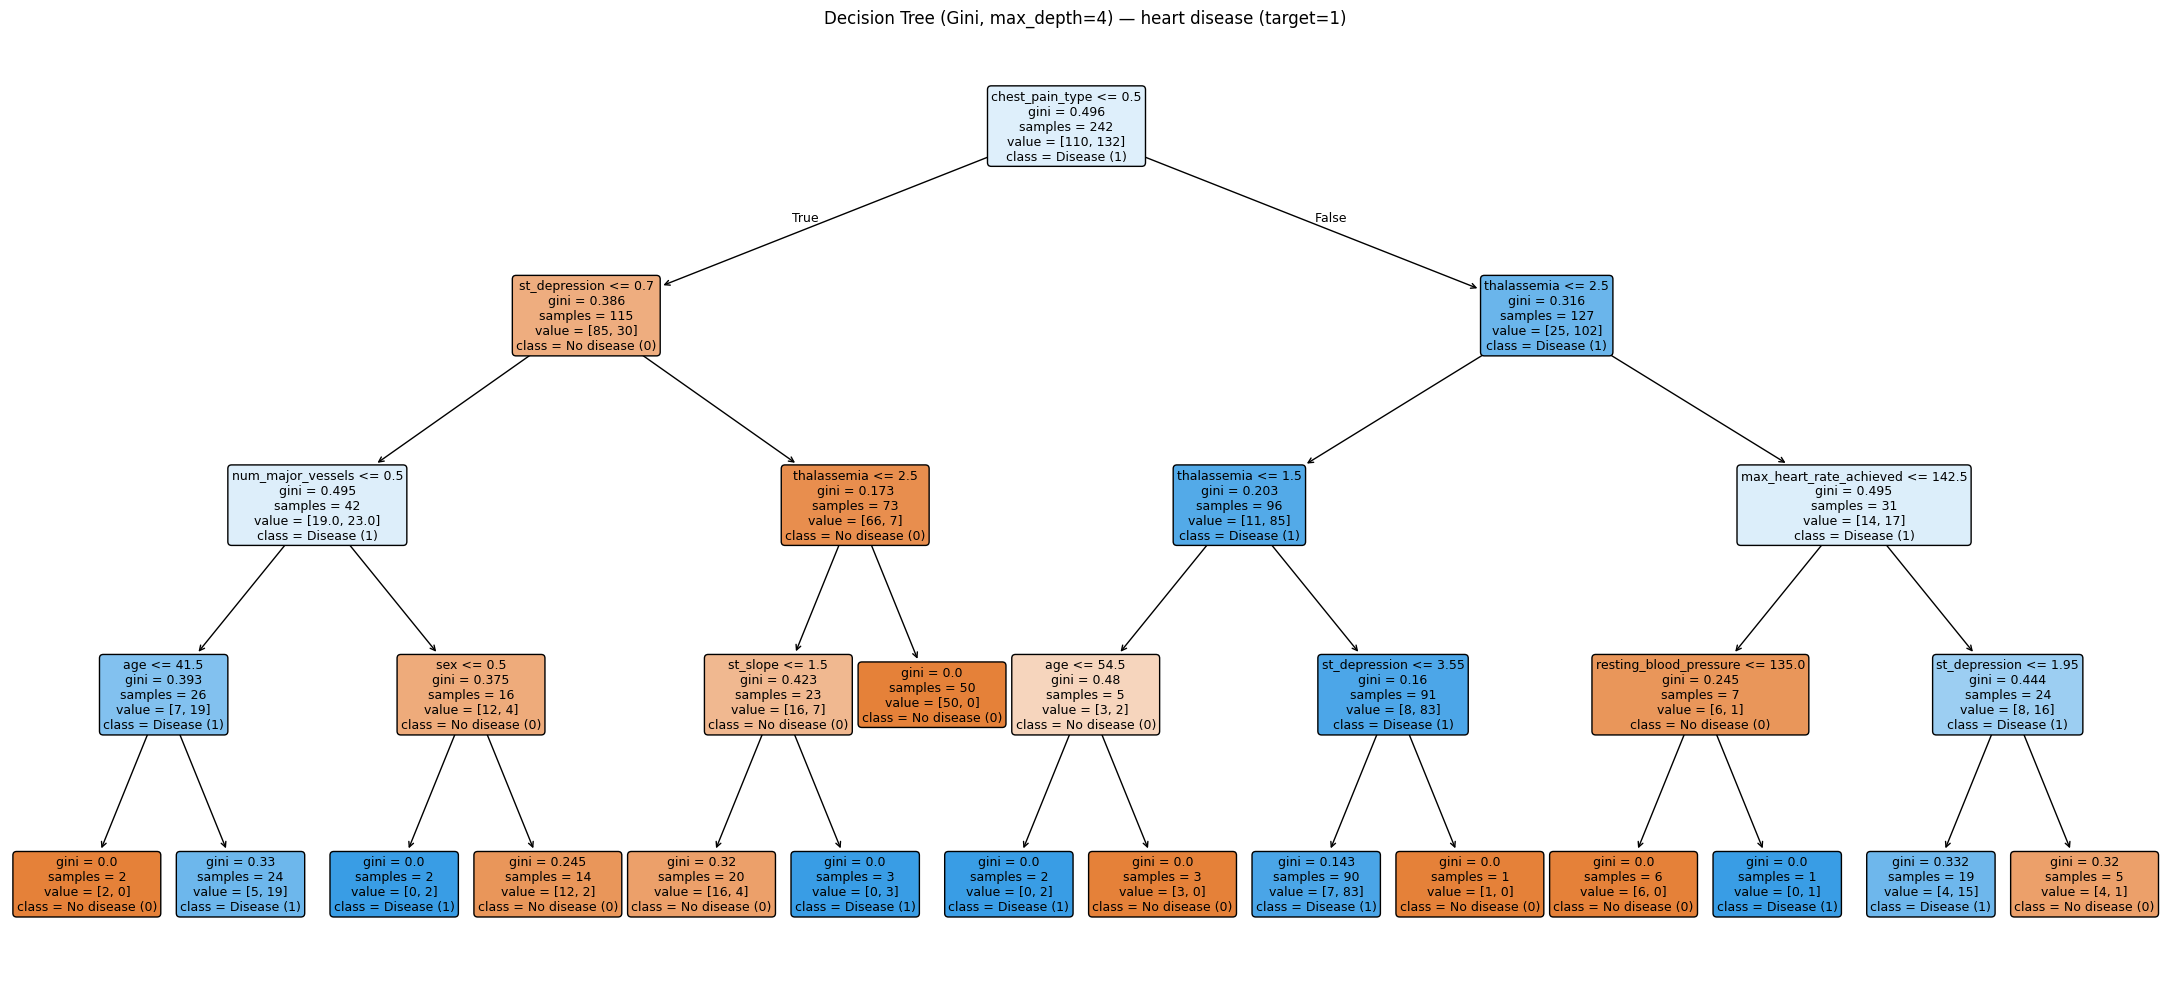

In [11]:
dt_clf = pipe_dt.named_steps["clf"]

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_clf,
    feature_names=feature_names,
    class_names=["No disease (0)", "Disease (1)"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree (Gini, max_depth=4) — heart disease (target=1)")
plt.tight_layout()
plt.show()

## Question 6 — Feature importance (Decision Tree vs Random Forest vs XGBoost)

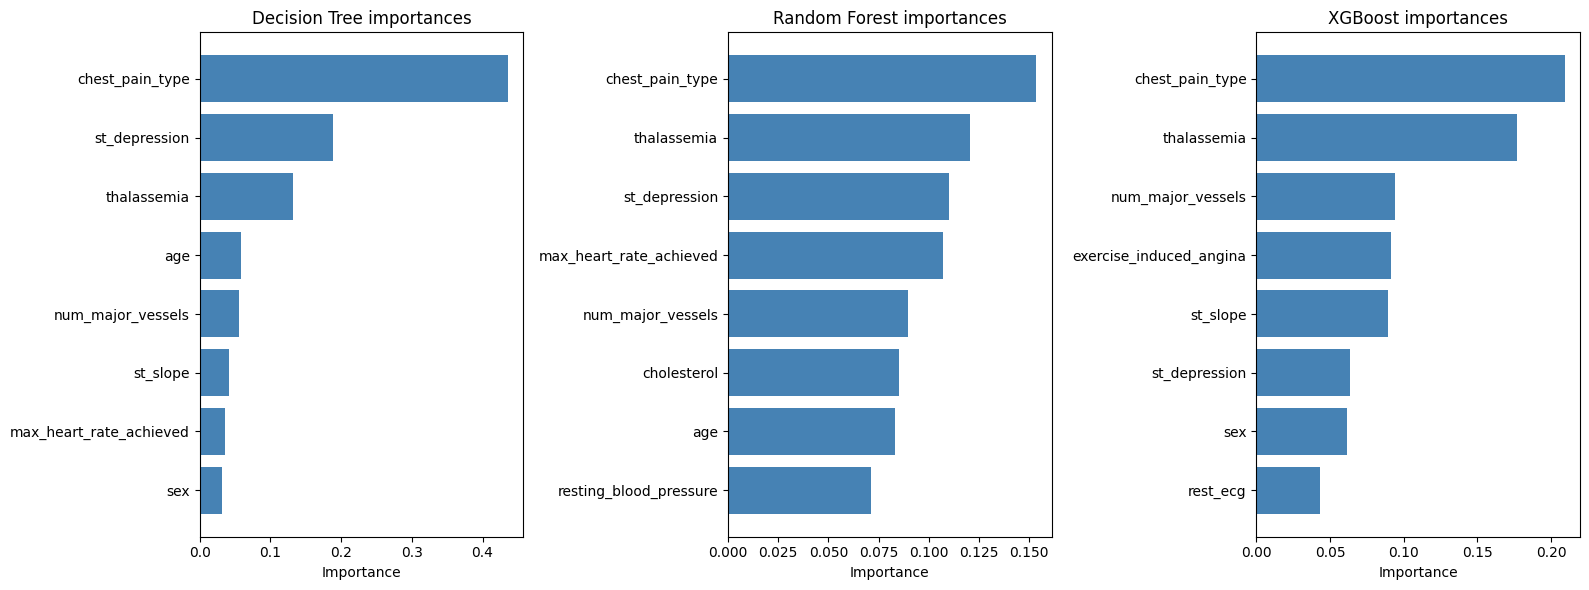

,feature,dt,rf,xgb
2,chest_pain_type,0.435904,0.153559,0.209061
12,thalassemia,0.131744,0.120534,0.176972
9,st_depression,0.188068,0.109890,0.063664
7,max_heart_rate_achieved,0.036522,0.106972,0.034805
11,num_major_vessels,0.056231,0.089831,0.093944
4,cholesterol,0.000000,0.085379,0.039139
0,age,0.057893,0.083454,0.040196
3,resting_blood_pressure,0.021053,0.071156,0.030473
8,exercise_induced_angina,0.000000,0.064650,0.091124
10,st_slope,0.041007,0.053776,0.089179


In [12]:
def top_importance_plot(importances, title, ax, top_n=8):
    idx = np.argsort(importances)[::-1][:top_n]
    names = [feature_names[i] for i in idx]
    vals = importances[idx]
    ax.barh(names[::-1], vals[::-1], color="steelblue")
    ax.set_title(title)


imp_dt = pipe_dt.named_steps["clf"].feature_importances_
imp_rf = pipe_rf.named_steps["clf"].feature_importances_
imp_xgb = pipe_xgb.named_steps["clf"].feature_importances_

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
top_importance_plot(imp_dt, "Decision Tree importances", axes[0])
top_importance_plot(imp_rf, "Random Forest importances", axes[1])
top_importance_plot(imp_xgb, "XGBoost importances", axes[2])

for ax in axes:
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

comparison = pd.DataFrame(
    {
        "feature": feature_names,
        "dt": imp_dt,
        "rf": imp_rf,
        "xgb": imp_xgb,
    }
).sort_values("rf", ascending=False)

display(comparison.head(12))

### Summary — held-out test metrics (all models)

In [13]:
metrics_df = pd.DataFrame(metrics_rows).set_index("model")
display(metrics_df.round(4))

best_f1 = metrics_df["f1"].idxmax()
print(f"Best test F1 (positive = disease): {best_f1}")

,accuracy,precision,recall,f1
model,,,,
Decision Tree (Gini),0.7869,0.7632,0.8788,0.8169
Gaussian Naive Bayes,0.8197,0.7895,0.9091,0.8451
Random Forest,0.8197,0.7619,0.9697,0.8533
XGBoost,0.7869,0.7632,0.8788,0.8169


Best test F1 (positive = disease): Random Forest
